# Roof Material Classification

This notebook trains a **single-label multiclass roof-material classifier** from the Vienna roof imagery.

The task is separate from the existing rooftop-element model:

- **Roof elements:** multi-label prediction of features such as chimney, solar, HVAC, skylight, and roof vegetation.
- **Roof material:** exactly one dominant material class per building roof.

The material annotations are used to identify the class of each building, while training uses the canonical roof crops in `data/raw/roofs/` so that the model is trained from the original imagery rather than the exported annotation copies.

The workflow follows the same general evaluation strategy as the existing roof-elements notebook:

1. validate annotations and imagery;
2. inspect class balance and image characteristics;
3. reserve a stratified held-out test set;
4. perform stratified cross-validation on the development set;
5. use two-stage ImageNet transfer learning with ResNet18;
6. select training duration from cross-validation;
7. retrain on all development data;
8. evaluate once on the held-out test set;
9. export the model, metrics, predictions, and figures.


In [1]:
# ================================================================
# IMPORTS
# ================================================================

from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
)
from sklearn.utils.class_weight import compute_class_weight


In [3]:
# ================================================================
# PROJECT PATHS
# ================================================================

def find_training_root(start: Path | None = None) -> Path:
    """Locate the training directory from anywhere inside the repository."""

    start = (start or Path.cwd()).resolve()

    for folder in [start, *start.parents]:
        if (
            (folder / "data").is_dir()
            and (folder / "notebooks").is_dir()
        ):
            return folder

    raise FileNotFoundError(
        "Could not locate the training directory. "
        "Run this notebook from inside the vienna_roof_explorer repository."
    )


TRAINING_ROOT = find_training_root()

DATA_DIR = TRAINING_ROOT / "data"

RAW_IMAGE_DIR = DATA_DIR / "raw" / "roofs"

MATERIAL_DATA_DIR = DATA_DIR / "roof_material"
MATERIAL_EXPORT_IMAGE_DIR = MATERIAL_DATA_DIR / "images"
CSV_PATH = MATERIAL_DATA_DIR / "annotations" / "roof_material.csv"

OUTPUT_DIR = TRAINING_ROOT / "outputs" / "roof_material"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"

for directory in [
    FIGURE_DIR,
    MODEL_DIR,
    RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


print(f"Training root       : {TRAINING_ROOT}")
print(f"Raw roof images     : {RAW_IMAGE_DIR}")
print(f"Material annotations: {CSV_PATH}")
print(f"Material outputs    : {OUTPUT_DIR}")


Training root       : C:\Users\Marco\Documents\vienna_roof_explorer\training
Raw roof images     : C:\Users\Marco\Documents\vienna_roof_explorer\training\data\raw\roofs
Material annotations: C:\Users\Marco\Documents\vienna_roof_explorer\training\data\roof_material\annotations\roof_material.csv
Material outputs    : C:\Users\Marco\Documents\vienna_roof_explorer\training\outputs\roof_material


## Dataset Provenance

The roof crops correspond to buildings selected from Vienna municipal geospatial data and orthophoto imagery. The same canonical `BW_*` roof crops used by the rooftop-element workflow are reused here.

Roof-material classes were annotated separately. The exported classification images are retained for traceability, but the model is trained from the canonical images in `data/raw/roofs/`, matched by `building_id`.

This prevents the annotation/export format from becoming the source imagery and keeps both roof-analysis tasks tied to the same building identifiers.


In [4]:
# ================================================================
# DATASET VALIDATION
# ================================================================

df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()

required_columns = [
    "building_id",
    "filename",
    "roof_material",
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required annotation columns: {missing_columns}"
    )


# ----------------------------------------------------------------
# Clean annotation fields
# ----------------------------------------------------------------

df["building_id"] = (
    df["building_id"]
    .astype(str)
    .str.strip()
)

df["filename"] = (
    df["filename"]
    .astype(str)
    .str.strip()
)

df["roof_material"] = (
    df["roof_material"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# ----------------------------------------------------------------
# Basic annotation checks
# ----------------------------------------------------------------

if df["building_id"].isna().any():
    raise ValueError("Missing building IDs detected.")

if df["roof_material"].isna().any():
    raise ValueError("Missing roof-material labels detected.")

duplicate_ids = (
    df.loc[
        df["building_id"].duplicated(keep=False),
        "building_id",
    ]
    .sort_values()
    .unique()
    .tolist()
)

if duplicate_ids:
    raise ValueError(
        "Duplicate building IDs detected. "
        "Each building must occur exactly once to avoid leakage.\n"
        f"{duplicate_ids}"
    )


# ----------------------------------------------------------------
# Match annotations to canonical raw roof crops
# ----------------------------------------------------------------

df["image_path"] = df["building_id"].apply(
    lambda building_id:
    RAW_IMAGE_DIR / f"{building_id}.png"
)

missing_raw_images = df.loc[
    ~df["image_path"].apply(Path.exists),
    ["building_id", "filename", "roof_material"],
]

if not missing_raw_images.empty:
    display(missing_raw_images)

    raise FileNotFoundError(
        "Some material annotations do not have a matching "
        "canonical image in data/raw/roofs."
    )


# ----------------------------------------------------------------
# Class vocabulary
# ----------------------------------------------------------------

CLASS_NAMES = sorted(
    df["roof_material"].unique().tolist()
)

CLASS_TO_INDEX = {
    label: index
    for index, label in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: label
    for label, index in CLASS_TO_INDEX.items()
}

df["target"] = df["roof_material"].map(
    CLASS_TO_INDEX
).astype(int)

NUM_CLASSES = len(CLASS_NAMES)

if NUM_CLASSES < 2:
    raise ValueError(
        "At least two roof-material classes are required."
    )


# ----------------------------------------------------------------
# Compare labeled and raw building IDs
# ----------------------------------------------------------------

raw_building_ids = {
    path.stem
    for path in RAW_IMAGE_DIR.glob("BW_*.png")
}

annotated_building_ids = set(df["building_id"])

unlabeled_raw_ids = sorted(
    raw_building_ids - annotated_building_ids
)

print("Dataset validation passed.\n")

print(f"Annotated buildings : {len(df)}")
print(f"Material classes    : {NUM_CLASSES}")
print(f"Canonical raw roofs : {len(raw_building_ids)}")
print(f"Unlabeled raw roofs : {len(unlabeled_raw_ids)}")

print("\nClasses:")
for index, label in enumerate(CLASS_NAMES):
    print(f"  {index}: {label}")

if unlabeled_raw_ids:
    print("\nRaw roofs without material labels:")
    print(unlabeled_raw_ids)

display(
    df[
        [
            "building_id",
            "filename",
            "roof_material",
            "target",
        ]
    ].head()
)


Dataset validation passed.

Annotated buildings : 95
Material classes    : 6
Canonical raw roofs : 95
Unlabeled raw roofs : 0

Classes:
  0: concrete
  1: gravel
  2: metal
  3: shingle
  4: tile
  5: unknown


,building_id,filename,roof_material,target
0,BW_5332839,BW_5332839_png.rf.hxTOPUfOIlNI1WwJEJ7u.png,concrete,0
1,BW_5287879,BW_5287879_png.rf.nv9iuSYbV7gDMkJMqHIM.png,gravel,1
2,BW_5327058,BW_5327058_png.rf.P7iCOKHkmknAdsE6Gjq5.png,gravel,1
3,BW_5332025,BW_5332025_png.rf.aTy2YIlrzIya8ROnkkiC.png,gravel,1
4,BW_5340550,BW_5340550_png.rf.UxbiCDd0C5XZhjo2ppzi.png,gravel,1


## Class Distribution

Roof material is a multiclass problem, so each building contributes to exactly one class. The class distribution is inspected before splitting because the dataset is small and some materials may be much less common than others.

Macro-F1 is used as the principal validation metric later so that performance on minority classes is not hidden by the dominant class.


,count,percentage
roof_material,,
concrete,1,1.05
gravel,24,25.26
metal,17,17.89
shingle,11,11.58
tile,23,24.21
unknown,19,20.00


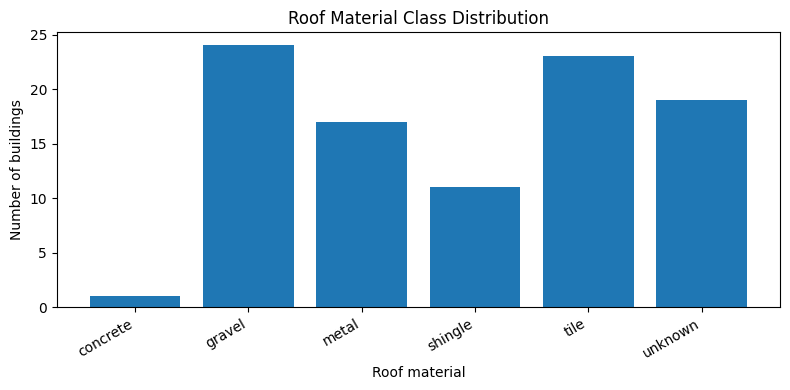

In [5]:
# ================================================================
# CLASS DISTRIBUTION
# ================================================================

class_distribution = (
    df["roof_material"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename("count")
    .to_frame()
)

class_distribution["percentage"] = (
    100
    * class_distribution["count"]
    / len(df)
)

display(
    class_distribution.round(2)
)


plt.figure(figsize=(8, 4))

plt.bar(
    class_distribution.index,
    class_distribution["count"],
)

plt.xlabel("Roof material")
plt.ylabel("Number of buildings")
plt.title("Roof Material Class Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "class_distribution.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## Image Characteristics

The material labels are linked back to the original roof crops. Inspecting their spatial dimensions confirms how much resizing is required before the images are passed to the ImageNet-pretrained network.


In [6]:
# ================================================================
# IMAGE CHARACTERISTICS
# ================================================================

image_records = []

for _, row in df.iterrows():

    image_path = row["image_path"]

    with Image.open(image_path) as image:
        width, height = image.size

    image_records.append({
        "building_id": row["building_id"],
        "roof_material": row["roof_material"],
        "width": width,
        "height": height,
        "aspect_ratio": width / height,
        "max_side": max(width, height),
        "pixel_count": width * height,
    })


image_stats = pd.DataFrame(image_records)

display(
    image_stats[
        [
            "width",
            "height",
            "aspect_ratio",
            "max_side",
            "pixel_count",
        ]
    ]
    .describe()
    .round(2)
)


,width,height,aspect_ratio,max_side,pixel_count
count,95.00,95.00,95.00,95.00,95.00
mean,381.29,364.09,1.10,423.94,209196.61
std,304.49,267.66,0.44,309.69,382748.93
min,128.00,115.00,0.38,128.00,14720.00
25%,195.50,191.00,0.80,203.50,35472.00
50%,255.00,261.00,1.05,308.00,71340.00
75%,429.50,422.00,1.25,556.00,194103.50
max,1644.00,1279.00,3.19,1644.00,2068143.00


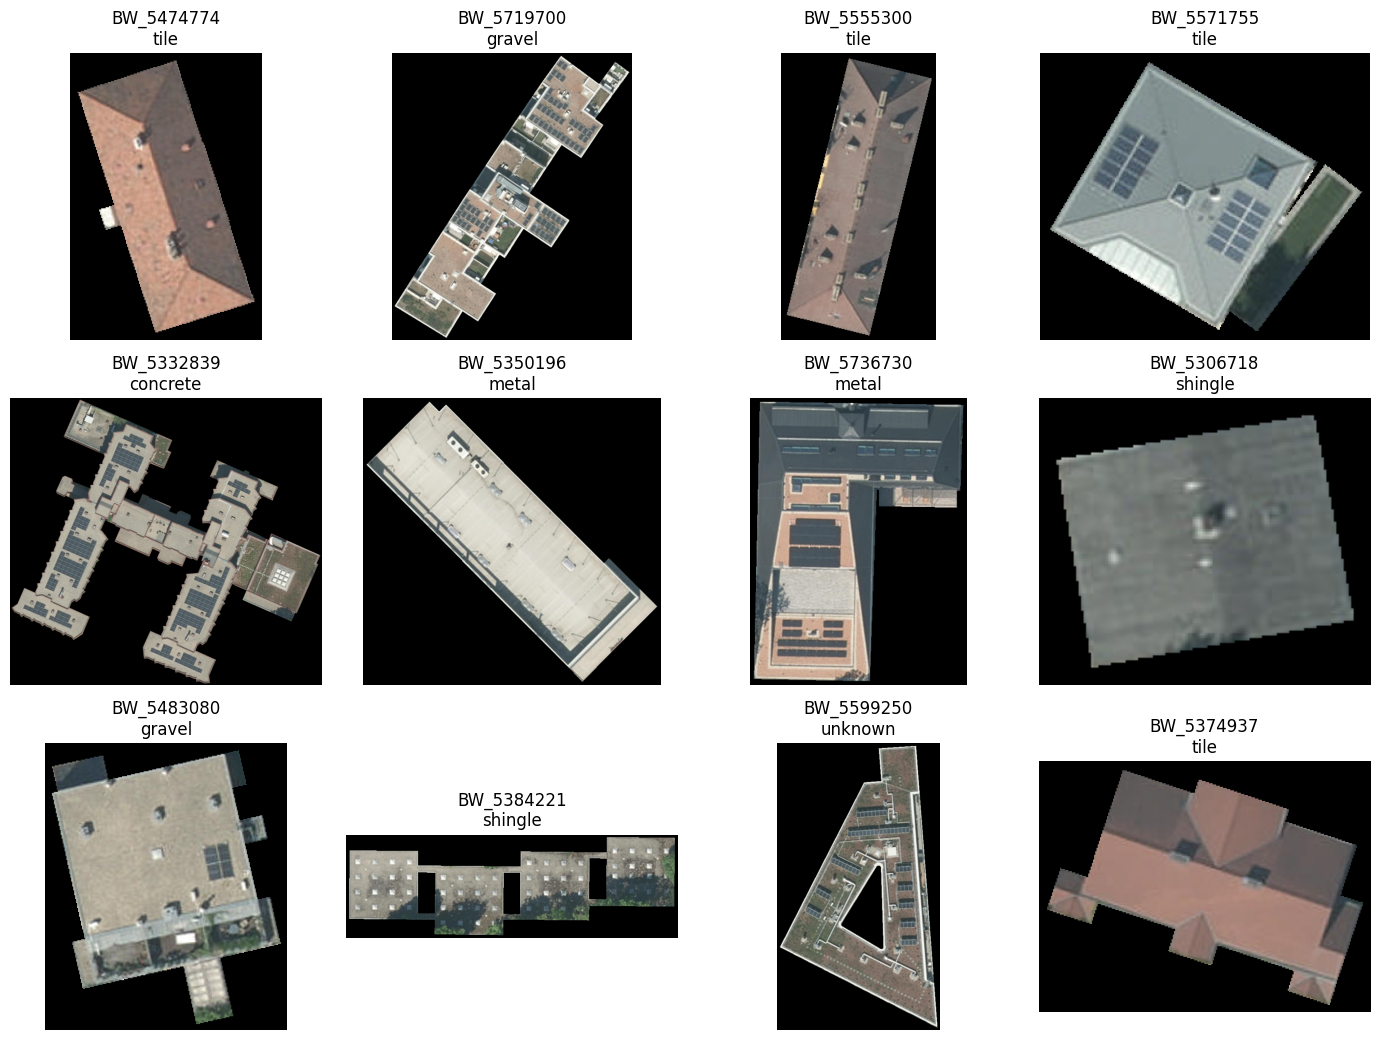

In [7]:
# ================================================================
# SAMPLE IMAGES
# ================================================================

sample_df = (
    df
    .sample(
        n=min(12, len(df)),
        random_state=42,
    )
    .reset_index(drop=True)
)

n_cols = 4
n_rows = int(np.ceil(len(sample_df) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 3.5 * n_rows),
)

axes = np.atleast_1d(axes).flatten()

for ax, (_, row) in zip(
    axes,
    sample_df.iterrows(),
):
    with Image.open(row["image_path"]) as image:
        ax.imshow(
            image.convert("RGB")
        )

    ax.set_title(
        f"{row['building_id']}\n"
        f"{row['roof_material']}"
    )

    ax.axis("off")


for ax in axes[len(sample_df):]:
    ax.axis("off")


plt.tight_layout()
plt.show()


## Development / Test Split

A **stratified 80/20 split** reserves a held-out test set before model selection.

The test set is not used to choose epochs, class weights, or model parameters. All model selection is performed only on the development set through stratified cross-validation.

Because the dataset is small, the notebook checks that every class has enough examples to support stratification.


In [8]:
# ================================================================
# DATA SPLITTING
# ================================================================

SEED = 42
TEST_SIZE = 0.20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ----------------------------------------------------------------
# Remove classes with insufficient samples
# ----------------------------------------------------------------

MIN_SAMPLES_PER_CLASS = 5

class_counts = (
    df["roof_material"]
    .value_counts()
)

rare_classes = class_counts[
    class_counts < MIN_SAMPLES_PER_CLASS
].index.tolist()


if rare_classes:

    print(
        "Classes excluded because they contain fewer than "
        f"{MIN_SAMPLES_PER_CLASS} samples:"
    )

    for class_name in rare_classes:
        print(
            f"  {class_name}: "
            f"{class_counts[class_name]} sample(s)"
        )

    df = (
        df[
            ~df["roof_material"].isin(
                rare_classes
            )
        ]
        .copy()
        .reset_index(drop=True)
    )


# ----------------------------------------------------------------
# Rebuild class indices after filtering
# ----------------------------------------------------------------

CLASS_NAMES = sorted(
    df["roof_material"]
    .unique()
    .tolist()
)

CLASS_TO_INDEX = {
    label: index
    for index, label in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: label
    for label, index in CLASS_TO_INDEX.items()
}

df["target"] = (
    df["roof_material"]
    .map(CLASS_TO_INDEX)
    .astype(int)
)

NUM_CLASSES = len(CLASS_NAMES)


print("\nClasses used for training:")

for class_name in CLASS_NAMES:
    n = (
        df["roof_material"]
        == class_name
    ).sum()

    print(
        f"  {class_name:<10}: {n}"
    )


# ----------------------------------------------------------------
# Stratified held-out test split
# ----------------------------------------------------------------

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

dev_idx, test_idx = next(
    splitter.split(
        df,
        df["target"],
    )
)


dev_df = (
    df.iloc[dev_idx]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df.iloc[test_idx]
    .copy()
    .reset_index(drop=True)
)


print("\nDataset split:")
print(f"Development samples : {len(dev_df)}")
print(f"Test samples        : {len(test_df)}")

Classes excluded because they contain fewer than 5 samples:
  concrete: 1 sample(s)

Classes used for training:
  gravel    : 24
  metal     : 17
  shingle   : 11
  tile      : 23
  unknown   : 19

Dataset split:
Development samples : 75
Test samples        : 19


In [9]:
# ================================================================
# SPLIT CLASS DISTRIBUTION
# ================================================================

split_distribution = pd.DataFrame({
    "all": (
        df["roof_material"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    ),
    "development": (
        dev_df["roof_material"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    ),
    "test": (
        test_df["roof_material"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    ),
})

display(split_distribution)


,all,development,test
roof_material,,,
gravel,24,19,5
metal,17,14,3
shingle,11,9,2
tile,23,18,5
unknown,19,15,4


### Cross-Validation Setup

The number of folds is chosen adaptively from the smallest class in the development set, with a maximum of five folds.

This avoids constructing a fold where a class is absent from the training or validation portion.


In [10]:
# ================================================================
# CROSS-VALIDATION SETUP
# ================================================================

MIN_DEV_CLASS_COUNT = int(
    dev_df["roof_material"]
    .value_counts()
    .min()
)

N_FOLDS = min(
    5,
    MIN_DEV_CLASS_COUNT,
)

if N_FOLDS < 2:
    raise ValueError(
        "The development set does not contain enough samples "
        "per class for cross-validation."
    )


cv = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)

cv_splits = list(
    cv.split(
        dev_df,
        dev_df["target"],
    )
)


print(f"Cross-validation folds: {N_FOLDS}")

fold_summary = []

for fold, (train_idx, val_idx) in enumerate(
    cv_splits,
    start=1,
):

    train_fold = dev_df.iloc[train_idx]
    val_fold = dev_df.iloc[val_idx]

    record = {
        "fold": fold,
        "train_n": len(train_fold),
        "val_n": len(val_fold),
    }

    for label in CLASS_NAMES:
        record[f"val_{label}"] = int(
            (val_fold["roof_material"] == label).sum()
        )

    fold_summary.append(record)


display(
    pd.DataFrame(fold_summary)
)


Cross-validation folds: 5


,fold,train_n,val_n,val_gravel,val_metal,val_shingle,val_tile,val_unknown
0,1,60,15,4,3,1,4,3
1,2,60,15,4,2,2,4,3
2,3,60,15,3,3,2,4,3
3,4,60,15,4,3,2,3,3
4,5,60,15,4,3,2,3,3


## Image Preprocessing

The original aspect ratio is preserved by padding each crop to a square before resizing to `320 × 320`.

Because the images are aerial roof crops without a preferred orientation, training augmentation includes rotations by multiples of 90° plus horizontal and vertical flips. Evaluation images are only padded, resized, converted to tensors, and ImageNet-normalized.


In [11]:
# ================================================================
# IMAGE PREPROCESSING
# ================================================================

IMAGE_SIZE = 320

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]


class PadToSquare:
    """Pad an image to a square while preserving aspect ratio."""

    def __call__(self, image):

        width, height = image.size
        max_side = max(width, height)

        pad_left = (max_side - width) // 2
        pad_right = (
            max_side
            - width
            - pad_left
        )

        pad_top = (max_side - height) // 2
        pad_bottom = (
            max_side
            - height
            - pad_top
        )

        return TF.pad(
            image,
            [
                pad_left,
                pad_top,
                pad_right,
                pad_bottom,
            ],
            fill=0,
        )


class Random90Rotation:
    """Randomly rotate aerial imagery by multiples of 90 degrees."""

    def __call__(self, image):

        angle = random.choice(
            [0, 90, 180, 270]
        )

        return TF.rotate(
            image,
            angle,
            expand=True,
            fill=0,
        )


train_transform = transforms.Compose([
    Random90Rotation(),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomVerticalFlip(
        p=0.5
    ),
    PadToSquare(),
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


eval_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


## PyTorch Dataset

Unlike the existing multi-label task, the target here is one integer class index per roof. This is the representation expected by `CrossEntropyLoss`.


In [12]:
# ================================================================
# PYTORCH DATASET
# ================================================================

class RoofMaterialDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )
        self.transform = transform


    def __len__(self):
        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        with Image.open(
            row["image_path"]
        ) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(
            int(row["target"]),
            dtype=torch.long,
        )

        return image, target


In [13]:
# ================================================================
# DATASET SANITY CHECK
# ================================================================

example_dataset = RoofMaterialDataset(
    dev_df,
    transform=eval_transform,
)

image, target = example_dataset[0]

print(f"Image tensor shape : {image.shape}")
print(f"Target             : {target.item()}")
print(f"Target class       : {INDEX_TO_CLASS[target.item()]}")
print(f"Classes            : {CLASS_NAMES}")


Image tensor shape : torch.Size([3, 320, 320])
Target             : 4
Target class       : unknown
Classes            : ['gravel', 'metal', 'shingle', 'tile', 'unknown']


## Model Architecture

An ImageNet-pretrained **ResNet18** is used as the backbone. Its final ImageNet classification layer is replaced by a linear layer with one logit for each roof-material class.

Softmax is only needed when converting logits into class probabilities during evaluation. `CrossEntropyLoss` receives the raw logits directly.


In [14]:
# ================================================================
# MODEL ARCHITECTURE
# ================================================================

def create_model():

    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    in_features = model.fc.in_features

    model.fc = nn.Linear(
        in_features,
        NUM_CLASSES,
    )

    return model


model = create_model()

print(model.fc)


# ----------------------------------------------------------------
# Model sanity check
# ----------------------------------------------------------------

model.eval()

with torch.no_grad():

    dummy_input = torch.randn(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    output = model(dummy_input)


print(f"Input shape : {dummy_input.shape}")
print(f"Output shape: {output.shape}")


Linear(in_features=512, out_features=5, bias=True)
Input shape : torch.Size([1, 3, 320, 320])
Output shape: torch.Size([1, 5])


## Loss Function and Class Imbalance

Multiclass classification is trained with `CrossEntropyLoss`.

To reduce bias toward common materials, balanced class weights are computed **from the training samples only**. During cross-validation, each fold therefore receives weights calculated only from that fold's training partition. This avoids using validation or test label frequencies when defining the loss.


In [15]:
# ================================================================
# CLASS-WEIGHT UTILITIES
# ================================================================

def calculate_class_weights(dataframe):
    """Calculate balanced multiclass weights from training data only."""

    targets = dataframe["target"].to_numpy()

    classes = np.arange(
        NUM_CLASSES
    )

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=targets,
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
    )


example_weights = calculate_class_weights(
    dev_df
)

display(
    pd.DataFrame({
        "class": CLASS_NAMES,
        "weight": example_weights.numpy(),
    }).round(3)
)


,class,weight
0,gravel,0.789
1,metal,1.071
2,shingle,1.667
3,tile,0.833
4,unknown,1.000


## Training Setup

The transfer-learning strategy mirrors the existing rooftop-element model:

- **Stage 1:** freeze the pretrained backbone and train only the new classification head.
- **Stage 2:** unfreeze ResNet `layer4` and continue fine-tuning it together with the classification head.

Batch-normalization running statistics remain frozen to reduce instability on this small dataset.


In [16]:
# ================================================================
# TRAINING SETUP
# ================================================================

BATCH_SIZE = 16

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


def create_dataloader(
    dataframe,
    transform,
    shuffle=False,
):

    dataset = RoofMaterialDataset(
        dataframe=dataframe,
        transform=transform,
    )

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(
            DEVICE.type == "cuda"
        ),
    )


print(f"Device     : {DEVICE}")
print(f"Batch size : {BATCH_SIZE}")


Device     : cuda
Batch size : 16


In [17]:
# ================================================================
# TRAINING AND VALIDATION UTILITIES
# ================================================================

def freeze_backbone(model):
    """Stage 1: train only the classification head."""

    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.fc.parameters():
        parameter.requires_grad = True


def unfreeze_layer4(model):
    """Stage 2: fine-tune layer4 and the classification head."""

    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    for parameter in model.fc.parameters():
        parameter.requires_grad = True


def freeze_batchnorm_stats(model):
    """Keep pretrained BatchNorm running statistics fixed."""

    for module in model.modules():
        if isinstance(
            module,
            nn.BatchNorm2d,
        ):
            module.eval()


def set_training_mode(
    model,
    stage,
):

    if stage == 1:

        model.eval()
        model.fc.train()

    elif stage == 2:

        model.train()
        freeze_batchnorm_stats(model)

    else:
        raise ValueError(
            "stage must be 1 or 2"
        )


def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    stage,
):

    set_training_mode(
        model,
        stage,
    )

    running_loss = 0.0
    n_samples = 0

    for images, targets in dataloader:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            targets,
        )

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        n_samples += batch_size

    return running_loss / n_samples


def evaluate_model(
    model,
    dataloader,
    criterion,
):
    """Evaluate mean loss and macro-F1."""

    model.eval()

    running_loss = 0.0
    n_samples = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():

        for images, targets in dataloader:

            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(images)

            loss = criterion(
                logits,
                targets,
            )

            predictions = (
                logits
                .argmax(dim=1)
            )

            batch_size = images.size(0)

            running_loss += (
                loss.item()
                * batch_size
            )

            n_samples += batch_size

            all_targets.append(
                targets.cpu().numpy()
            )

            all_predictions.append(
                predictions.cpu().numpy()
            )


    y_true = np.concatenate(
        all_targets
    )

    y_pred = np.concatenate(
        all_predictions
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    mean_loss = (
        running_loss
        / n_samples
    )

    return mean_loss, macro_f1


In [18]:
# ================================================================
# OPTIMIZER CONFIGURATION
# ================================================================

STAGE1_LR = 1e-3

STAGE2_BACKBONE_LR = 1e-5
STAGE2_HEAD_LR = 1e-4

WEIGHT_DECAY = 1e-4


def create_stage1_optimizer(model):

    freeze_backbone(model)

    return torch.optim.AdamW(
        model.fc.parameters(),
        lr=STAGE1_LR,
        weight_decay=WEIGHT_DECAY,
    )


def create_stage2_optimizer(model):

    unfreeze_layer4(model)

    return torch.optim.AdamW(
        [
            {
                "params":
                    model.layer4.parameters(),
                "lr":
                    STAGE2_BACKBONE_LR,
            },
            {
                "params":
                    model.fc.parameters(),
                "lr":
                    STAGE2_HEAD_LR,
            },
        ],
        weight_decay=WEIGHT_DECAY,
    )


## Cross-Validation Training

Each fold starts from a fresh ImageNet-pretrained ResNet18. The best epoch in each stage is selected by validation **macro-F1**.

The fold-specific class weights are calculated only from that fold's training subset.


In [19]:
# ================================================================
# CROSS-VALIDATION TRAINING
# ================================================================

STAGE1_EPOCHS = 30
STAGE2_EPOCHS = 20

cv_results = []
cv_history = []


for fold, (train_idx, val_idx) in enumerate(
    cv_splits,
    start=1,
):

    print("=" * 70)
    print(f"FOLD {fold}/{N_FOLDS}")
    print("=" * 70)


    train_fold = (
        dev_df.iloc[train_idx]
        .copy()
        .reset_index(drop=True)
    )

    val_fold = (
        dev_df.iloc[val_idx]
        .copy()
        .reset_index(drop=True)
    )


    # ------------------------------------------------------------
    # DataLoaders
    # ------------------------------------------------------------

    train_loader = create_dataloader(
        train_fold,
        transform=train_transform,
        shuffle=True,
    )

    val_loader = create_dataloader(
        val_fold,
        transform=eval_transform,
        shuffle=False,
    )


    # ------------------------------------------------------------
    # Weighted multiclass loss
    # ------------------------------------------------------------

    class_weights = (
        calculate_class_weights(
            train_fold
        )
        .to(DEVICE)
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )


    # Fresh pretrained model for each fold
    model = create_model().to(DEVICE)


    # ============================================================
    # STAGE 1 - CLASSIFICATION HEAD
    # ============================================================

    optimizer = create_stage1_optimizer(
        model
    )

    best_stage1_f1 = -np.inf
    best_stage1_epoch = None
    best_stage1_state = None

    stage1_train_losses = []
    stage1_val_losses = []
    stage1_val_f1 = []


    for epoch in range(
        1,
        STAGE1_EPOCHS + 1,
    ):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            stage=1,
        )

        val_loss, val_f1 = evaluate_model(
            model,
            val_loader,
            criterion,
        )

        stage1_train_losses.append(
            train_loss
        )

        stage1_val_losses.append(
            val_loss
        )

        stage1_val_f1.append(
            val_f1
        )


        if val_f1 > best_stage1_f1:

            best_stage1_f1 = val_f1
            best_stage1_epoch = epoch

            best_stage1_state = copy.deepcopy(
                model.state_dict()
            )


    print(
        f"Stage 1 | "
        f"Best epoch: {best_stage1_epoch:2d} | "
        f"Macro F1: {best_stage1_f1:.3f}"
    )


    model.load_state_dict(
        best_stage1_state
    )


    # ============================================================
    # STAGE 2 - LAYER4 + CLASSIFICATION HEAD
    # ============================================================

    optimizer = create_stage2_optimizer(
        model
    )

    best_stage2_f1 = -np.inf
    best_stage2_epoch = None
    best_stage2_state = None

    stage2_train_losses = []
    stage2_val_losses = []
    stage2_val_f1 = []


    for epoch in range(
        1,
        STAGE2_EPOCHS + 1,
    ):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            stage=2,
        )

        val_loss, val_f1 = evaluate_model(
            model,
            val_loader,
            criterion,
        )

        stage2_train_losses.append(
            train_loss
        )

        stage2_val_losses.append(
            val_loss
        )

        stage2_val_f1.append(
            val_f1
        )


        if val_f1 > best_stage2_f1:

            best_stage2_f1 = val_f1
            best_stage2_epoch = epoch

            best_stage2_state = copy.deepcopy(
                model.state_dict()
            )


    print(
        f"Stage 2 | "
        f"Best epoch: {best_stage2_epoch:2d} | "
        f"Macro F1: {best_stage2_f1:.3f}"
    )


    cv_results.append({
        "fold": fold,
        "stage1_macro_f1":
            best_stage1_f1,
        "stage1_best_epoch":
            best_stage1_epoch,
        "stage2_macro_f1":
            best_stage2_f1,
        "stage2_best_epoch":
            best_stage2_epoch,
    })


    cv_history.append({
        "fold": fold,

        "stage1_train_loss":
            stage1_train_losses,
        "stage1_val_loss":
            stage1_val_losses,
        "stage1_val_f1":
            stage1_val_f1,

        "stage2_train_loss":
            stage2_train_losses,
        "stage2_val_loss":
            stage2_val_losses,
        "stage2_val_f1":
            stage2_val_f1,
    })


cv_results = pd.DataFrame(
    cv_results
)

display(cv_results.round(3))


print("\nMean validation Macro F1")

print(
    f"Stage 1: "
    f"{cv_results['stage1_macro_f1'].mean():.3f}"
)

print(
    f"Stage 2: "
    f"{cv_results['stage2_macro_f1'].mean():.3f}"
)


FOLD 1/5
Stage 1 | Best epoch:  6 | Macro F1: 0.543
Stage 2 | Best epoch: 17 | Macro F1: 0.531
FOLD 2/5
Stage 1 | Best epoch:  7 | Macro F1: 0.721
Stage 2 | Best epoch:  7 | Macro F1: 0.786
FOLD 3/5
Stage 1 | Best epoch: 10 | Macro F1: 0.853
Stage 2 | Best epoch:  4 | Macro F1: 0.787
FOLD 4/5
Stage 1 | Best epoch: 24 | Macro F1: 0.549
Stage 2 | Best epoch: 16 | Macro F1: 0.531
FOLD 5/5
Stage 1 | Best epoch: 22 | Macro F1: 0.518
Stage 2 | Best epoch: 16 | Macro F1: 0.577


,fold,stage1_macro_f1,stage1_best_epoch,stage2_macro_f1,stage2_best_epoch
0,1,0.543,6,0.531,17
1,2,0.721,7,0.786,7
2,3,0.853,10,0.787,4
3,4,0.549,24,0.531,16
4,5,0.518,22,0.577,16



Mean validation Macro F1
Stage 1: 0.637
Stage 2: 0.642


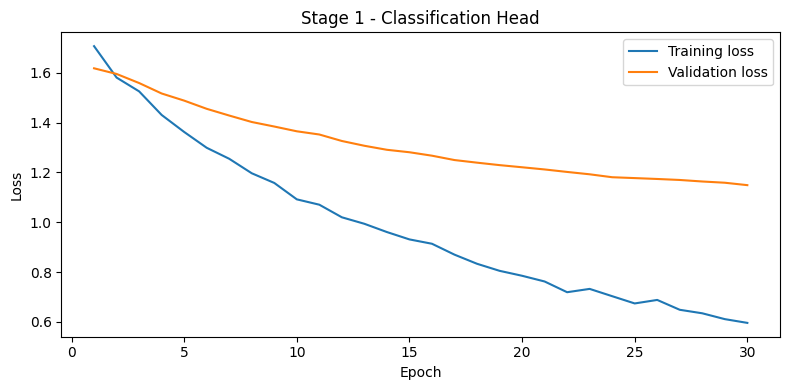

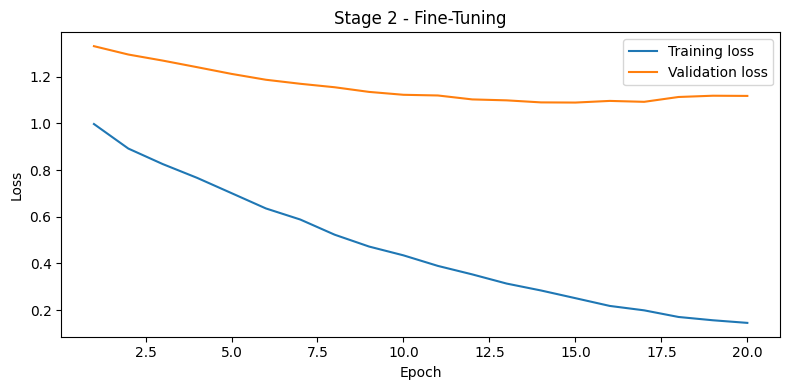

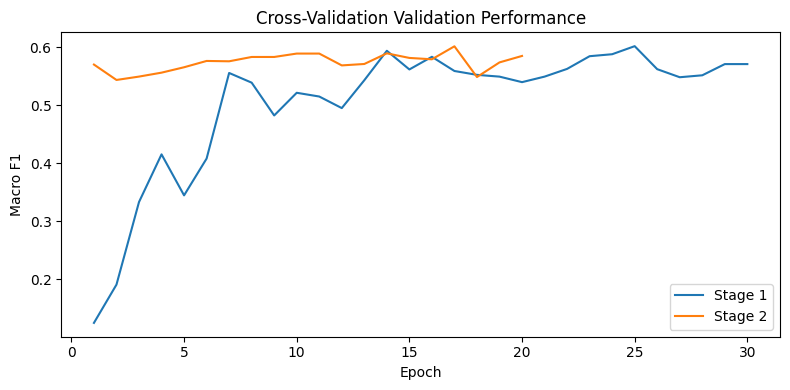

In [20]:
# ================================================================
# CROSS-VALIDATION LEARNING CURVES
# ================================================================

stage1_train_mean = np.mean(
    [
        history["stage1_train_loss"]
        for history in cv_history
    ],
    axis=0,
)

stage1_val_mean = np.mean(
    [
        history["stage1_val_loss"]
        for history in cv_history
    ],
    axis=0,
)

stage1_f1_mean = np.mean(
    [
        history["stage1_val_f1"]
        for history in cv_history
    ],
    axis=0,
)

stage2_train_mean = np.mean(
    [
        history["stage2_train_loss"]
        for history in cv_history
    ],
    axis=0,
)

stage2_val_mean = np.mean(
    [
        history["stage2_val_loss"]
        for history in cv_history
    ],
    axis=0,
)

stage2_f1_mean = np.mean(
    [
        history["stage2_val_f1"]
        for history in cv_history
    ],
    axis=0,
)


# ----------------------------------------------------------------
# Stage 1 loss
# ----------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, STAGE1_EPOCHS + 1),
    stage1_train_mean,
    label="Training loss",
)

plt.plot(
    range(1, STAGE1_EPOCHS + 1),
    stage1_val_mean,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 - Classification Head")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "cv_stage1_loss.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------
# Stage 2 loss
# ----------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, STAGE2_EPOCHS + 1),
    stage2_train_mean,
    label="Training loss",
)

plt.plot(
    range(1, STAGE2_EPOCHS + 1),
    stage2_val_mean,
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 2 - Fine-Tuning")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "cv_stage2_loss.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------------
# Validation Macro F1
# ----------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    range(1, STAGE1_EPOCHS + 1),
    stage1_f1_mean,
    label="Stage 1",
)

plt.plot(
    range(1, STAGE2_EPOCHS + 1),
    stage2_f1_mean,
    label="Stage 2",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Cross-Validation Validation Performance")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "cv_macro_f1.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


In [21]:
# ================================================================
# CROSS-VALIDATION SUMMARY
# ================================================================

FINAL_STAGE1_EPOCHS = max(
    1,
    int(
        cv_results[
            "stage1_best_epoch"
        ].median()
    ),
)

FINAL_STAGE2_EPOCHS = max(
    1,
    int(
        cv_results[
            "stage2_best_epoch"
        ].median()
    ),
)


print(
    f"Stage 1 mean Macro F1: "
    f"{cv_results['stage1_macro_f1'].mean():.3f}"
)

print(
    f"Stage 2 mean Macro F1: "
    f"{cv_results['stage2_macro_f1'].mean():.3f}"
)

print(
    f"\nFinal Stage 1 epochs: "
    f"{FINAL_STAGE1_EPOCHS}"
)

print(
    f"Final Stage 2 epochs: "
    f"{FINAL_STAGE2_EPOCHS}"
)


Stage 1 mean Macro F1: 0.637
Stage 2 mean Macro F1: 0.642

Final Stage 1 epochs: 10
Final Stage 2 epochs: 16


## Final Model Training

After cross-validation, a fresh ResNet18 is trained on the complete development set.

The median best epoch from the cross-validation folds determines the duration of each transfer-learning stage. The held-out test set remains untouched until the next section.


In [22]:
# ================================================================
# FINAL MODEL TRAINING
# ================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


final_train_loader = create_dataloader(
    dev_df,
    transform=train_transform,
    shuffle=True,
)


final_class_weights = (
    calculate_class_weights(
        dev_df
    )
    .to(DEVICE)
)

final_criterion = nn.CrossEntropyLoss(
    weight=final_class_weights
)


final_model = create_model().to(
    DEVICE
)


# ================================================================
# STAGE 1
# ================================================================

optimizer = create_stage1_optimizer(
    final_model
)

print("Stage 1")

for epoch in range(
    1,
    FINAL_STAGE1_EPOCHS + 1,
):

    train_loss = train_one_epoch(
        final_model,
        final_train_loader,
        final_criterion,
        optimizer,
        stage=1,
    )

    print(
        f"Epoch {epoch:2d}/"
        f"{FINAL_STAGE1_EPOCHS} "
        f"| Loss: {train_loss:.4f}"
    )


# ================================================================
# STAGE 2
# ================================================================

optimizer = create_stage2_optimizer(
    final_model
)

print("\nStage 2")

for epoch in range(
    1,
    FINAL_STAGE2_EPOCHS + 1,
):

    train_loss = train_one_epoch(
        final_model,
        final_train_loader,
        final_criterion,
        optimizer,
        stage=2,
    )

    print(
        f"Epoch {epoch:2d}/"
        f"{FINAL_STAGE2_EPOCHS} "
        f"| Loss: {train_loss:.4f}"
    )


print("\nFinal model training complete.")


Stage 1
Epoch  1/10 | Loss: 1.6618
Epoch  2/10 | Loss: 1.5437
Epoch  3/10 | Loss: 1.4725
Epoch  4/10 | Loss: 1.3884
Epoch  5/10 | Loss: 1.3178
Epoch  6/10 | Loss: 1.2518
Epoch  7/10 | Loss: 1.2083
Epoch  8/10 | Loss: 1.1326
Epoch  9/10 | Loss: 1.0986
Epoch 10/10 | Loss: 1.0356

Stage 2
Epoch  1/16 | Loss: 1.0074
Epoch  2/16 | Loss: 0.9043
Epoch  3/16 | Loss: 0.8129
Epoch  4/16 | Loss: 0.7559
Epoch  5/16 | Loss: 0.6574
Epoch  6/16 | Loss: 0.5939
Epoch  7/16 | Loss: 0.5093
Epoch  8/16 | Loss: 0.4857
Epoch  9/16 | Loss: 0.4203
Epoch 10/16 | Loss: 0.3530
Epoch 11/16 | Loss: 0.3558
Epoch 12/16 | Loss: 0.3260
Epoch 13/16 | Loss: 0.2537
Epoch 14/16 | Loss: 0.2599
Epoch 15/16 | Loss: 0.2146
Epoch 16/16 | Loss: 0.1935

Final model training complete.


## Held-Out Test Evaluation

The final model is evaluated once on the reserved test set.

For each image, softmax converts the model logits into mutually exclusive class probabilities and the highest-probability class becomes the prediction.

The main reported metrics are:

- accuracy;
- balanced accuracy;
- macro-F1;
- weighted-F1;
- per-class precision, recall, and F1;
- confusion matrix.

Macro-F1 is especially important here because it gives every material class equal importance regardless of its frequency.


In [23]:
# ================================================================
# HELD-OUT TEST EVALUATION
# ================================================================

test_loader = create_dataloader(
    test_df,
    transform=eval_transform,
    shuffle=False,
)


final_model.eval()

all_targets = []
all_probabilities = []


with torch.no_grad():

    for images, targets in test_loader:

        images = images.to(DEVICE)

        logits = final_model(
            images
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        all_targets.append(
            targets.numpy()
        )

        all_probabilities.append(
            probabilities.cpu().numpy()
        )


y_true = np.concatenate(
    all_targets
)

y_prob = np.vstack(
    all_probabilities
)

y_pred = y_prob.argmax(
    axis=1
)


# ----------------------------------------------------------------
# Overall metrics
# ----------------------------------------------------------------

test_accuracy = accuracy_score(
    y_true,
    y_pred,
)

test_balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred,
)

test_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0,
)

test_weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)


print(
    f"Test Accuracy          : "
    f"{test_accuracy:.3f}"
)

print(
    f"Test Balanced Accuracy : "
    f"{test_balanced_accuracy:.3f}"
)

print(
    f"Test Macro F1          : "
    f"{test_macro_f1:.3f}"
)

print(
    f"Test Weighted F1       : "
    f"{test_weighted_f1:.3f}"
)


# ----------------------------------------------------------------
# Per-class metrics
# ----------------------------------------------------------------

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(
            NUM_CLASSES
        ),
        zero_division=0,
    )
)


per_class_results = pd.DataFrame({
    "class": CLASS_NAMES,
    "support": support,
    "precision": precision,
    "recall": recall,
    "f1": f1,
}).set_index("class")


display(
    per_class_results.round(3)
)


Test Accuracy          : 0.579
Test Balanced Accuracy : 0.580
Test Macro F1          : 0.490
Test Weighted F1       : 0.520


,support,precision,recall,f1
class,,,,
gravel,5,0.500,0.4,0.444
metal,3,0.000,0.0,0.000
shingle,2,0.400,1.0,0.571
tile,5,0.625,1.0,0.769
unknown,4,1.000,0.5,0.667


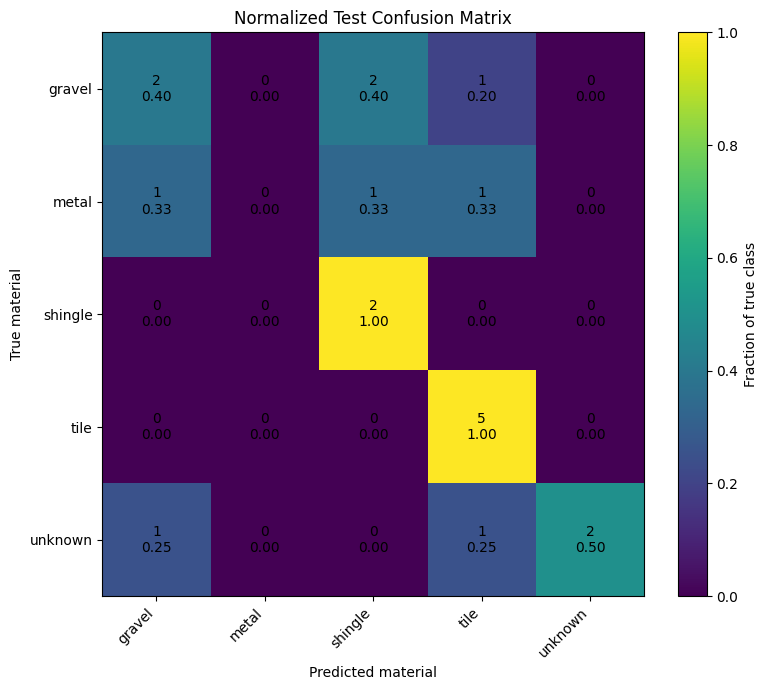

In [24]:
# ================================================================
# CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    ),
)

row_sums = cm.sum(
    axis=1,
    keepdims=True,
)

cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(
        cm,
        dtype=float,
    ),
    where=row_sums != 0,
)


plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm_normalized,
    interpolation="nearest",
    aspect="auto",
)

plt.colorbar(
    label="Fraction of true class"
)

plt.xticks(
    np.arange(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45,
    ha="right",
)

plt.yticks(
    np.arange(NUM_CLASSES),
    CLASS_NAMES,
)

plt.xlabel("Predicted material")
plt.ylabel("True material")
plt.title("Normalized Test Confusion Matrix")


for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):

        plt.text(
            j,
            i,
            f"{cm[i, j]}\n"
            f"{cm_normalized[i, j]:.2f}",
            ha="center",
            va="center",
        )


plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "test_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


In [25]:
# ================================================================
# TEST PREDICTIONS
# ================================================================

prediction_results = test_df[
    [
        "building_id",
        "filename",
        "roof_material",
    ]
].copy()

prediction_results = prediction_results.rename(
    columns={
        "roof_material":
            "true_material"
    }
)

prediction_results["predicted_material"] = [
    INDEX_TO_CLASS[index]
    for index in y_pred
]

prediction_results["confidence"] = (
    y_prob.max(axis=1)
)

prediction_results["correct"] = (
    prediction_results[
        "true_material"
    ]
    == prediction_results[
        "predicted_material"
    ]
)


for class_index, class_name in enumerate(
    CLASS_NAMES
):
    prediction_results[
        f"prob_{class_name}"
    ] = y_prob[:, class_index]


display(
    prediction_results
    .sort_values(
        [
            "correct",
            "confidence",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


,building_id,filename,true_material,predicted_material,confidence,correct,prob_gravel,prob_metal,prob_shingle,prob_tile,prob_unknown
0,BW_5467157,BW_5467157_png.rf.vYykHAwh4mKLD0xjsdTL.png,metal,gravel,0.748378,False,0.748378,0.089071,0.091837,0.037119,0.033595
1,BW_5725913,BW_5725913_png.rf.6z9frk09jFkIc9sETz5q.png,unknown,gravel,0.724042,False,0.724042,0.004409,0.000435,0.023167,0.247947
2,BW_5542925,BW_5542925_png.rf.vA5Yjf6ZDm8mGxkwZpyK.png,gravel,shingle,0.702234,False,0.187715,0.012575,0.702234,0.070560,0.026916
3,BW_5548732,BW_5548732_png.rf.PZeg0ywpf3ggW2ictq7X.png,metal,tile,0.681762,False,0.005494,0.241121,0.071558,0.681762,0.000064
4,BW_5467776,BW_5467776_png.rf.ECaLnKcCDny2UXSiuOIs.png,gravel,shingle,0.523875,False,0.333521,0.079493,0.523875,0.004057,0.059055
5,BW_5545631,BW_5545631_png.rf.BsBvPCf8g764c1qSwaWU.png,metal,shingle,0.477666,False,0.066434,0.333577,0.477666,0.085327,0.036996
6,BW_5621659,BW_5621659_png.rf.RBPixyf3ibYONoanoc3N.png,unknown,tile,0.468625,False,0.208934,0.043284,0.098863,0.468625,0.180295
7,BW_5425424,BW_5425424_png.rf.H2mgs4dtN4zBkwoYnJ4L.png,gravel,tile,0.378751,False,0.234387,0.036029,0.331415,0.378751,0.019417
8,BW_5571755,BW_5571755_png.rf.PUGku0z3eJQmgabg1BJd.png,tile,tile,0.967911,True,0.007305,0.006477,0.008851,0.967911,0.009455
9,BW_5416597,BW_5416597_png.rf.JZmGcSO1wYtPfeuhX5PZ.png,tile,tile,0.967239,True,0.003153,0.002776,0.026111,0.967239,0.000721


## Model Export

The exported checkpoint includes the class order and preprocessing configuration required for inference. This is important because the integer class indices only have meaning together with the stored `classes` list.


In [26]:
# ================================================================
# MODEL EXPORT
# ================================================================

FINAL_MODEL_PATH = (
    MODEL_DIR
    / "roof_material_resnet18.pth"
)


torch.save(
    {
        "model_state_dict":
            final_model.state_dict(),

        "architecture":
            "resnet18",

        "classes":
            CLASS_NAMES,

        "class_to_index":
            CLASS_TO_INDEX,

        "image_size":
            IMAGE_SIZE,

        "imagenet_mean":
            IMAGENET_MEAN,

        "imagenet_std":
            IMAGENET_STD,

        "stage1_epochs":
            FINAL_STAGE1_EPOCHS,

        "stage2_epochs":
            FINAL_STAGE2_EPOCHS,

        "seed":
            SEED,
    },
    FINAL_MODEL_PATH,
)


print(
    f"Model saved to:\n"
    f"{FINAL_MODEL_PATH}"
)


Model saved to:
C:\Users\Marco\Documents\vienna_roof_explorer\training\outputs\roof_material\models\roof_material_resnet18.pth


In [27]:
# ================================================================
# SAVE RESULTS
# ================================================================

cv_results.to_csv(
    RESULTS_DIR
    / "cross_validation_results.csv",
    index=False,
)

per_class_results.to_csv(
    RESULTS_DIR
    / "test_per_class_results.csv"
)

prediction_results.to_csv(
    RESULTS_DIR
    / "test_predictions.csv",
    index=False,
)


overall_results = pd.DataFrame({
    "metric": [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1",
    ],
    "value": [
        test_accuracy,
        test_balanced_accuracy,
        test_macro_f1,
        test_weighted_f1,
    ],
})


overall_results.to_csv(
    RESULTS_DIR
    / "test_overall_results.csv",
    index=False,
)


class_distribution.to_csv(
    RESULTS_DIR
    / "class_distribution.csv"
)


print("Results saved:")
print(RESULTS_DIR)


Results saved:
C:\Users\Marco\Documents\vienna_roof_explorer\training\outputs\roof_material\results


## Interpretation Notes

This dataset is intentionally treated as a proof-of-concept material classifier.

Important limitations to consider when interpreting the results:

- the dataset is small, so per-class test metrics may have high variance;
- some roof materials can be visually ambiguous at orthophoto resolution;
- mixed-material roofs are reduced to one dominant label;
- `unknown`, if present, represents visual uncertainty rather than a physical material;
- roof vegetation remains a separate rooftop-element property rather than being treated as the underlying construction material.

The confusion matrix is therefore particularly informative: it shows which material categories the available imagery can and cannot reliably distinguish.
